# DDPM National Tambon Impact (Gold) — Climate Hazards | B.E. 2560–2567

Phase 2 notebook (read-only over Gold facts):
- Reads Gold fact tables built by [`build_gold_ddpm_tambon_impact_climate_2560_2567.py`](../ELT/build_gold_ddpm_tambon_impact_climate_2560_2567.py:1)
- Joins to Silver enriched tambon geometry by **6-digit DOPA code only** (`subdistrict_code` ↔ `subdist_cd`)
- Visualizes **whole-country** choropleths for each available metric

Guardrails:
- No name-based fallback joins
- Names are taken from the Gold spine (already embedded into the Gold fact table)


In [1]:
from __future__ import annotations

import sys
import re
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

# --- Thai text rendering (best-effort) ---
thai_font_candidates = [
    'TH Sarabun New',
    'Sarabun',
    'Noto Sans Thai',
    'Tahoma',
    'Angsana New',
    'Cordia New',
]
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
thai_font = next((_f for _f in thai_font_candidates if _f in available_fonts), None)
if thai_font is not None:
    mpl.rcParams['font.family'] = thai_font
mpl.rcParams['axes.unicode_minus'] = False

# --- Global readability tuning: +2pt across the board ---
mpl.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
})

# Notebook-relative root (data_system/)
BASE_PATH = Path.cwd().resolve().parent.parent  # .../data_system
print('BASE_PATH =', BASE_PATH)

FACT_PATH = BASE_PATH / 'data/2_gold/ddpm/fact_ddpm_tambon_impact_climate_2560_2567.csv'
YEARLY_PATH = BASE_PATH / 'data/2_gold/ddpm/fact_ddpm_tambon_impact_climate_yearly_2560_2567.csv'
TAMBON_SHP_PATH = BASE_PATH / 'data/1_silver/dopa/tambon_boundaries_enriched.shp'
PROVINCE_BRONZE_SHP_PATH = BASE_PATH / 'data/0_bronze/dopa/thailanda-administrative-boundary/THA_Province.shp'

assert FACT_PATH.exists(), FACT_PATH
assert YEARLY_PATH.exists(), YEARLY_PATH
assert TAMBON_SHP_PATH.exists(), TAMBON_SHP_PATH
assert PROVINCE_BRONZE_SHP_PATH.exists(), PROVINCE_BRONZE_SHP_PATH


BASE_PATH = C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system


## 1) Load Gold facts + Silver geometry
We will join by code only:
- Gold: `subdistrict_code` (6 digits)
- Geometry: `subdist_cd` (6 digits)


In [2]:
def _read_csv_flex(path: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(path, encoding='utf-8')
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='cp874')

def _extract_digits(value: object) -> str:
    if value is None:
        return ''
    s = str(value).strip()
    m = re.search(r'(\d+)', s)
    return m.group(1) if m else ''

def _clean_code_6(series: pd.Series) -> pd.Series:
    s = series.astype(str)
    s = s.str.replace(r'\.0$', '', regex=True).str.strip()
    s = s.map(_extract_digits)
    s = s.str[-6:].fillna('')
    s = s.where(s.str.fullmatch(r'\d{6}', na=False), '')
    s = s.where(~s.isin(['', '000000', 'nan', 'None']), '')
    return s

fact = _read_csv_flex(FACT_PATH)
yearly = _read_csv_flex(YEARLY_PATH)
gdf = gpd.read_file(TAMBON_SHP_PATH)
gdf_prov_bronze = gpd.read_file(PROVINCE_BRONZE_SHP_PATH)

print('fact.shape =', fact.shape)
print('yearly.shape =', yearly.shape)
print('gdf.shape =', gdf.shape)
print('gdf_prov_bronze.shape =', gdf_prov_bronze.shape)

required_fact_cols = {'subdistrict_code'}
missing = required_fact_cols.difference(fact.columns)
if missing:
    raise KeyError(f'Missing columns in fact: {sorted(missing)}')
if 'subdist_cd' not in gdf.columns:
    raise KeyError("Geometry is missing 'subdist_cd'. Columns: " + str(list(gdf.columns)))

fact = fact.copy()
fact['subdistrict_code'] = _clean_code_6(fact['subdistrict_code'])
fact = fact.loc[fact['subdistrict_code'].ne('')].copy()

gdf = gdf.copy()
gdf['subdist_cd'] = _clean_code_6(gdf['subdist_cd'])
gdf = gdf.loc[gdf['subdist_cd'].ne('')].copy()

# Keep geometry lean for plotting performance
geom_keep_cols = ['subdist_cd', 'P_NAME_T', 'A_NAME_T', 'T_NAME_T', 'geometry']
geom_keep_cols = [c for c in geom_keep_cols if c in gdf.columns]
gdf = gdf[geom_keep_cols].copy()

# Bronze province boundaries for overlay (visual only)
gdf_prov_bronze = gdf_prov_bronze.to_crs(gdf.crs)
prov_keep_cols = ['geometry']
if 'P_CODE' in gdf_prov_bronze.columns: prov_keep_cols.insert(0, 'P_CODE')
if 'P_NAME_T' in gdf_prov_bronze.columns: prov_keep_cols.insert(0, 'P_NAME_T')
gdf_prov_bronze = gdf_prov_bronze[prov_keep_cols].copy()

# Join for mapping (left join from geometry is OK; missing stats => 0 for maps)
map_df = gdf.merge(fact, left_on='subdist_cd', right_on='subdistrict_code', how='left')
print('map_df.shape =', map_df.shape)


fact.shape = (6967, 13)
yearly.shape = (55736, 8)
gdf.shape = (8125, 10)
gdf_prov_bronze.shape = (77, 4)
map_df.shape = (8125, 18)


## 2) National integrity checks (non-negotiable)
This notebook re-checks the hard QA property that should already hold from the Gold build:
- `stats_codes ⊆ geometry_codes`


In [3]:
stat_codes = set(fact['subdistrict_code'].unique().tolist())
geom_codes = set(gdf['subdist_cd'].unique().tolist())
missing_geom = sorted(stat_codes.difference(geom_codes))
print('Unique stat codes   =', len(stat_codes))
print('Unique geometry codes=', len(geom_codes))
print('Missing geometry codes (should be 0) =', len(missing_geom))
if missing_geom:
    display(pd.DataFrame({'subdistrict_code': missing_geom}).head(50))
    raise RuntimeError(f'Stats→geometry coverage failed inside notebook: {len(missing_geom)} missing codes')

# Quick duplicate checks
dup_fact = int(fact['subdistrict_code'].duplicated().sum())
dup_geom = int(gdf['subdist_cd'].duplicated().sum())
print('Duplicate subdistrict_code rows in fact:', dup_fact)
print('Duplicate subdist_cd rows in geometry (expected >0? depends on shapefile):', dup_geom)


Unique stat codes   = 6967
Unique geometry codes= 7436
Missing geometry codes (should be 0) = 0
Duplicate subdistrict_code rows in fact: 0
Duplicate subdist_cd rows in geometry (expected >0? depends on shapefile): 689


## 3) Metric discovery (what we will map)
We will map *every numeric* metric from the Gold fact table **except** join keys and obvious identifiers.

Default exclusions: `subdistrict_code`, `province_code`, name fields.
If you want to exclude percentiles or only map raw metrics, change the filter below.


In [4]:
id_cols = {
    'subdistrict_code',
    'province_code',
    'province_name_th',
    'district_name_th',
    'subdistrict_name_th',
}

numeric_cols = [c for c in fact.columns if c not in id_cols and pd.api.types.is_numeric_dtype(fact[c])]
numeric_cols = sorted(numeric_cols)
print('Numeric metric columns (fact):')
for c in numeric_cols:
    print(' -', c)

# Fill missing numeric stats as 0 for mapping (geometry rows with no disasters in window)
for c in numeric_cols:
    map_df[c] = pd.to_numeric(map_df[c], errors='coerce').fillna(0)


Numeric metric columns (fact):
 - affected_households_sum
 - affected_people_sum
 - avg_yoy_change
 - deaths_sum
 - pct_national_affected_households_sum
 - pct_national_affected_people_sum
 - pct_national_avg_yoy_change
 - pct_national_deaths_sum


## 4) Whole-country choropleths (one map per metric)
Rendering guidance:
- National tambon polygons are heavy. Prefer static maps (GeoPandas + Matplotlib).
- To reduce outlier domination, we clip each metric at the 99th percentile for color scaling (values are unchanged in the data table; only the plotted color scale is clipped).

If the notebook becomes slow, we can later switch to province-first maps or raster tiles, but this cell is the simplest whole-country view.


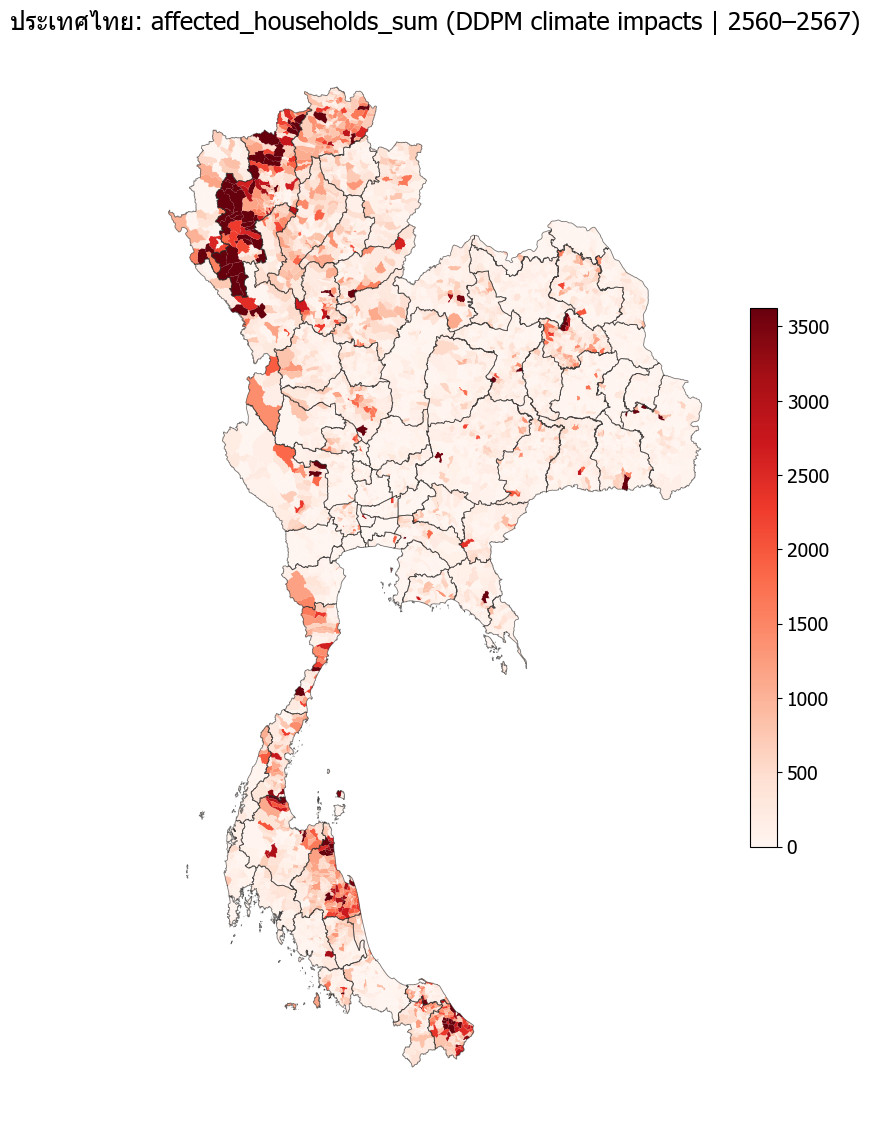

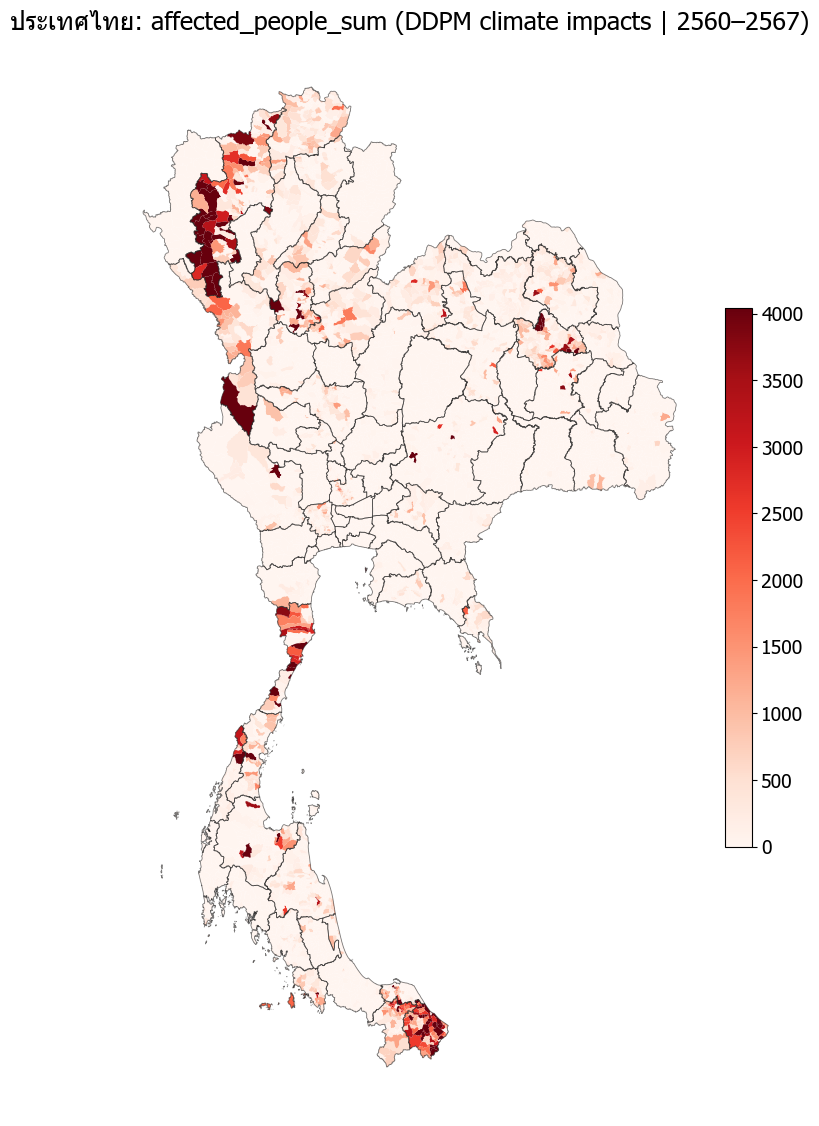

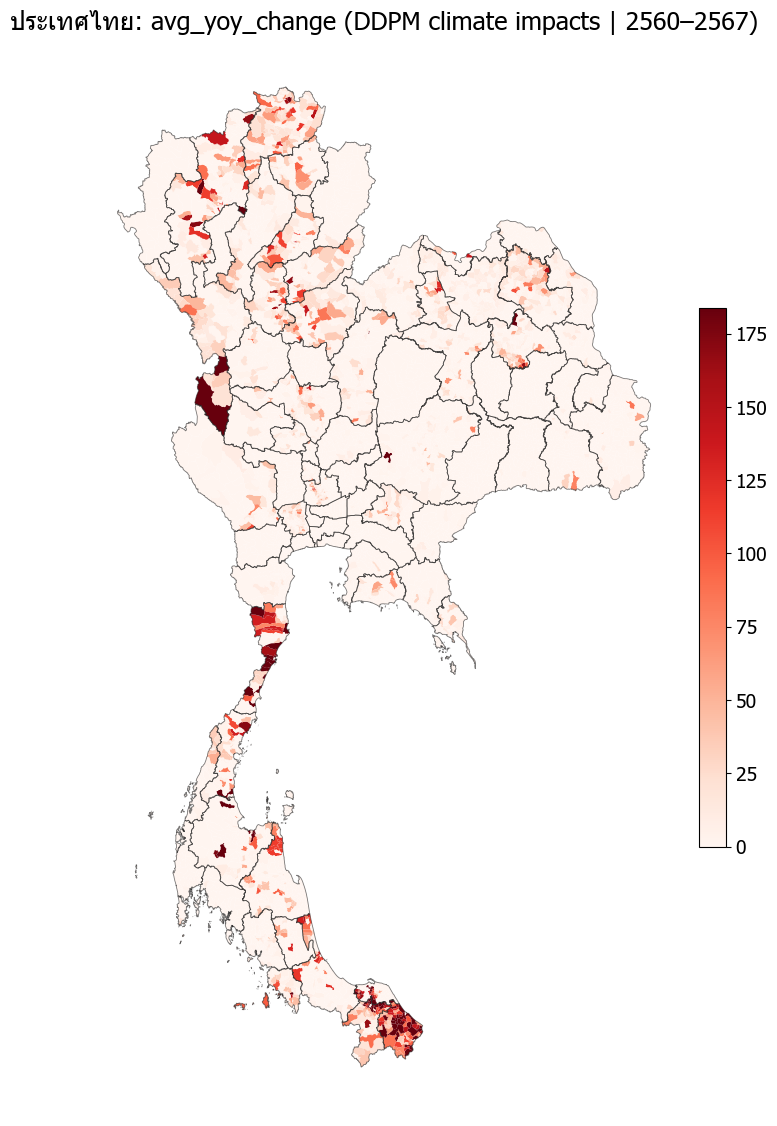

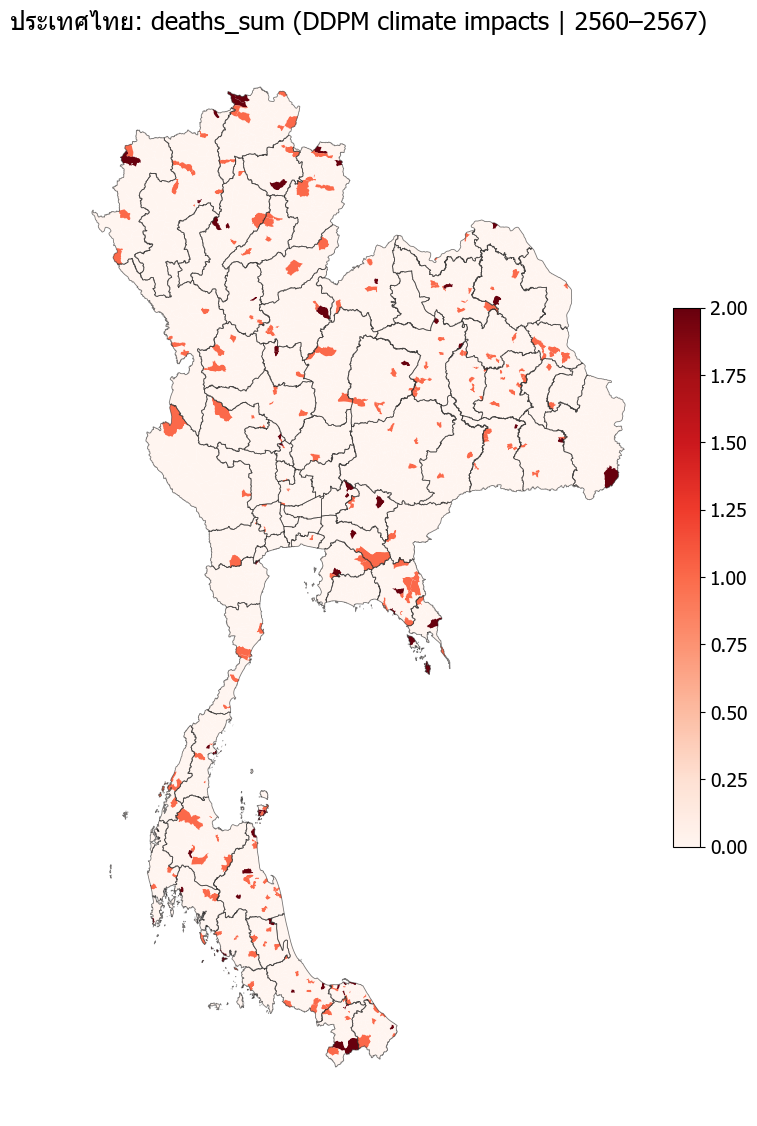

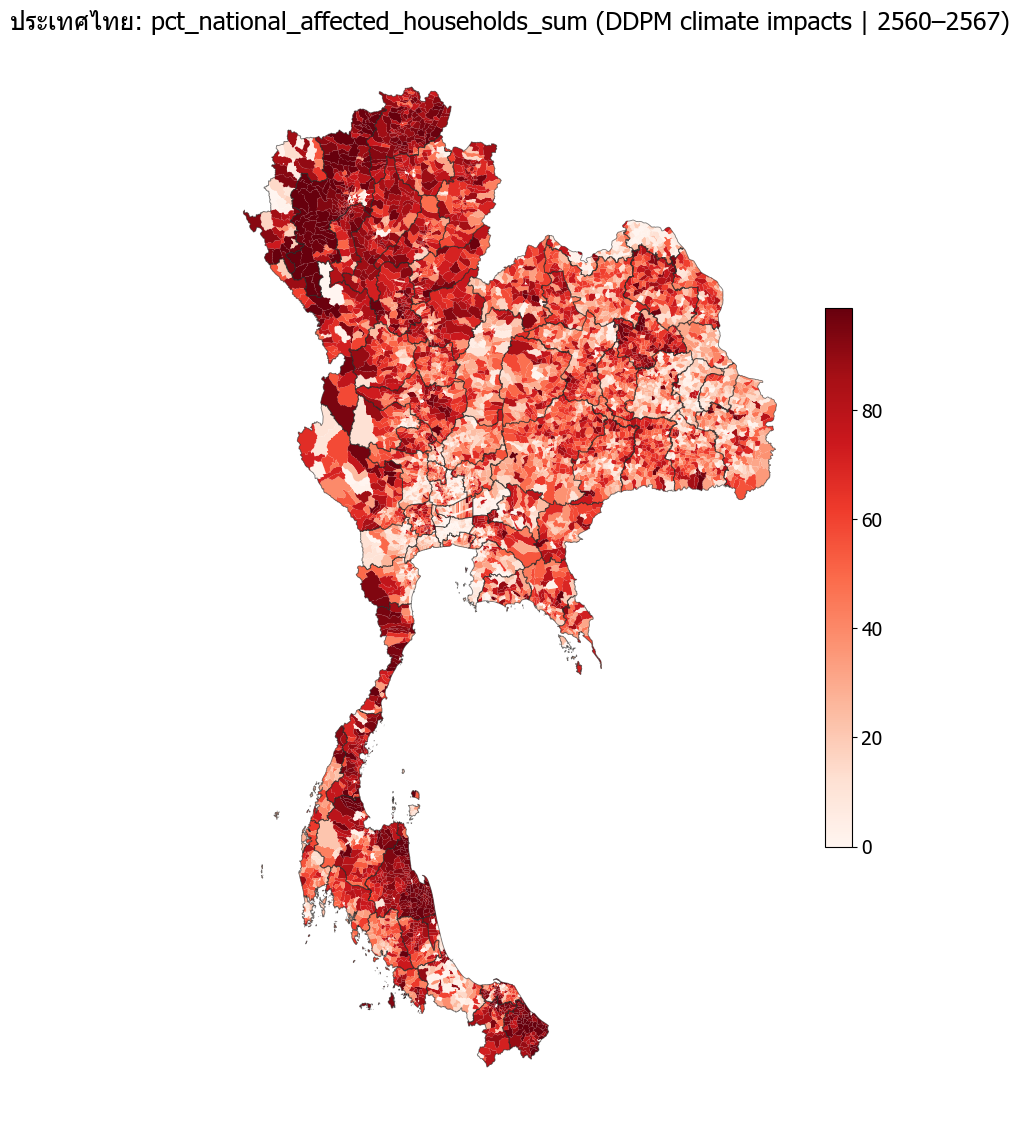

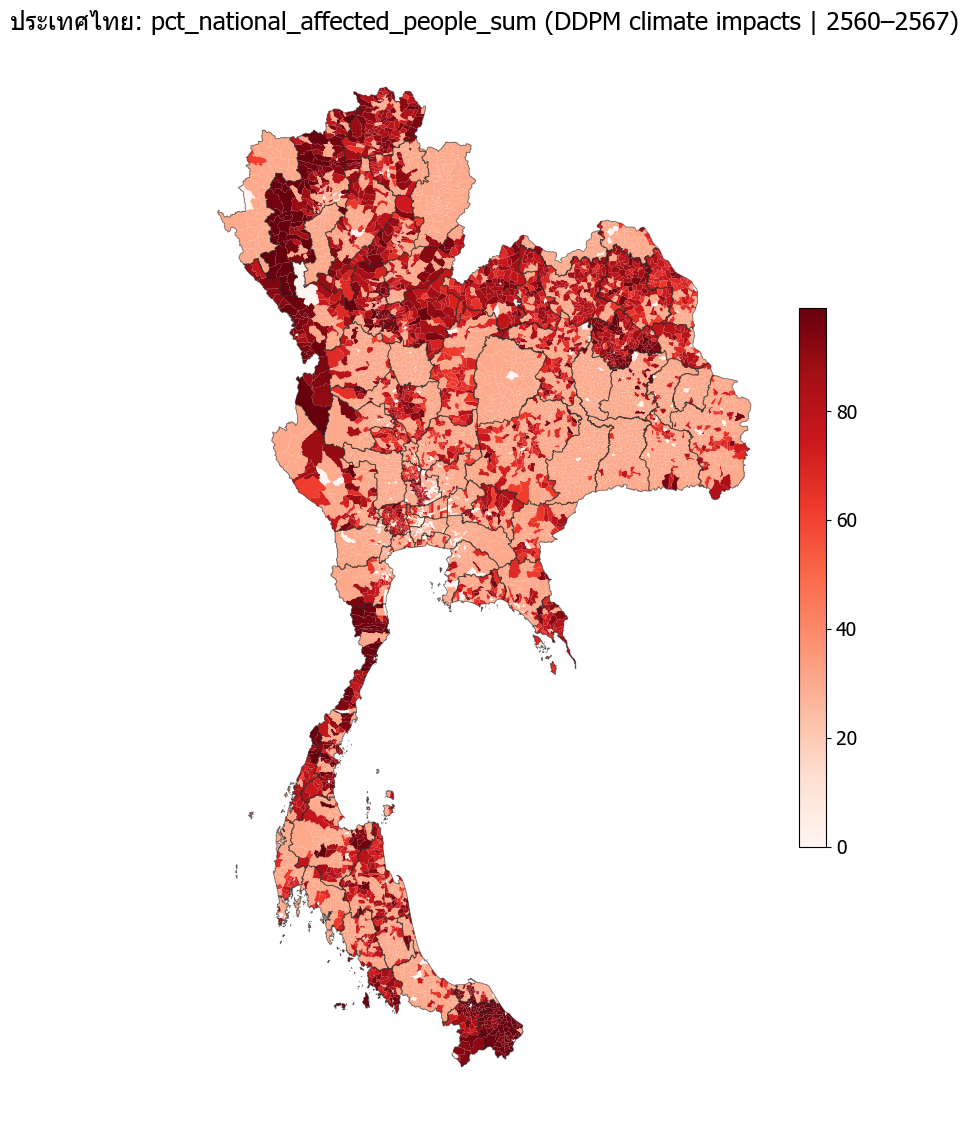

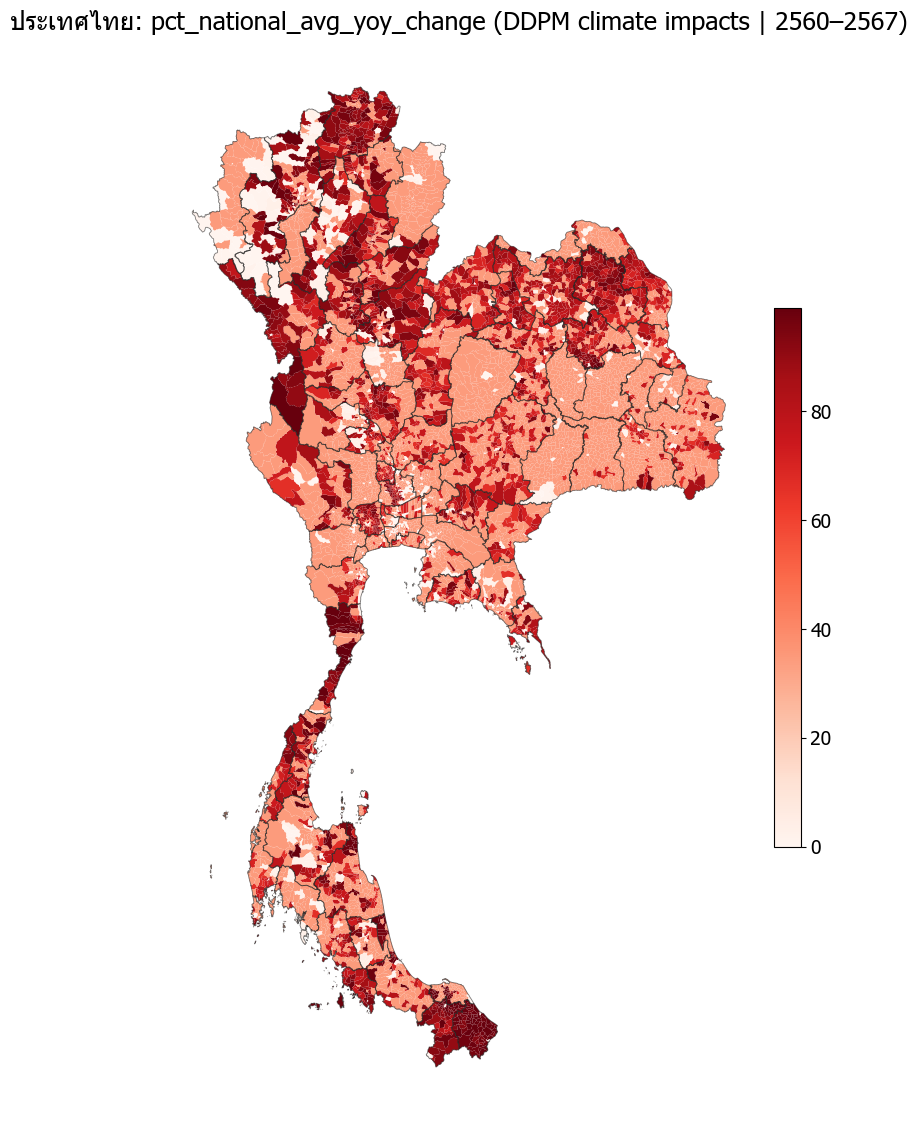

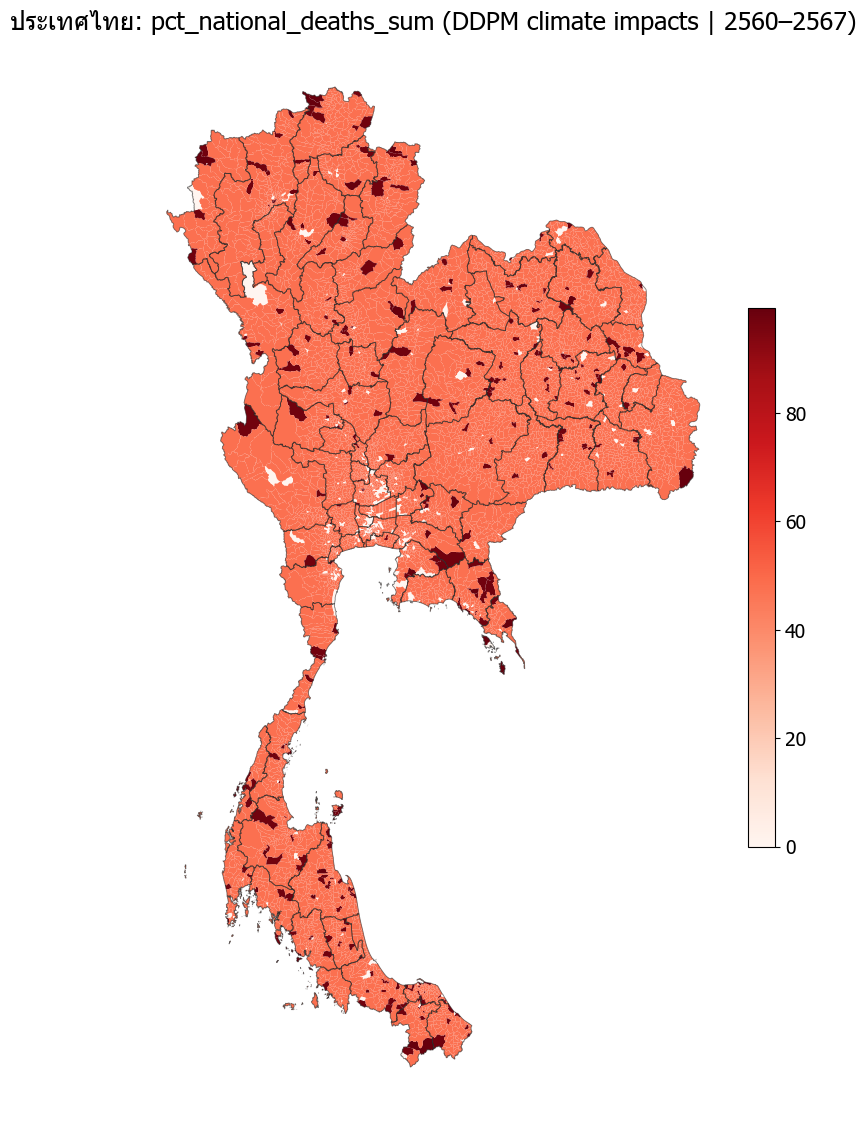

In [5]:
def plot_national_metric(gdf_metrics: gpd.GeoDataFrame, metric: str, *, cmap: str = 'Reds', prov_borders: gpd.GeoDataFrame | None = None) -> None:
    # Clip only for display scale
    values = pd.to_numeric(gdf_metrics[metric], errors='coerce').fillna(0)
    vmax = float(values.quantile(0.99)) if len(values) else 0.0
    vmax = max(vmax, 0.0)

    fig, ax = plt.subplots(1, 1, figsize=(14, 14))
    ax.set_title(f'ประเทศไทย: {metric} (DDPM climate impacts | 2560–2567)', fontsize=18)
    ax.set_axis_off()

    gdf_metrics.plot(
        column=metric,
        ax=ax,
        cmap=cmap,
        legend=True,
        legend_kwds={
            'shrink': 0.5,
            'fraction': 0.03,
            'pad': 0.02,
        },
        linewidth=0.0,
        edgecolor='none',
        vmin=0,
        vmax=vmax if vmax > 0 else None,
        missing_kwds={
            'color': '#f0f0f0',
            'edgecolor': 'none',
            'hatch': None,
            'label': 'No data',
        },
    )

    # Overlay province boundaries (Bronze) for map readability
    if prov_borders is not None:
        try:
            prov_borders.boundary.plot(ax=ax, color='#222222', linewidth=0.6, alpha=0.6)
        except Exception:
            pass
    plt.show()

# Run one map per metric
for metric in numeric_cols:
    plot_national_metric(map_df, metric, cmap='Reds', prov_borders=gdf_prov_bronze)


## 5) Basic national summary tables
Lightweight arithmetic/statistics over the Gold fact table (no recompute of ETL).


In [6]:
display(fact.head())

# National totals (over tambons)
totals = {m: float(pd.to_numeric(fact[m], errors='coerce').fillna(0).sum()) for m in numeric_cols}
totals_df = pd.DataFrame([totals]).T.reset_index().rename(columns={'index': 'metric', 0: 'sum_all_tambons'})
display(totals_df.sort_values('sum_all_tambons', ascending=False).head(50))

# Top 20 tambons per raw metric (exclude percentiles by default)
raw_metrics = [m for m in numeric_cols if not m.startswith('pct_')]
for m in raw_metrics:
    top = fact.sort_values(m, ascending=False).head(20)[
        ['subdistrict_code', 'province_name_th', 'district_name_th', 'subdistrict_name_th', m]
    ]
    print(f'Top 20 tambons by {m}:')
    display(top)


,subdistrict_code,province_code,affected_households_sum,affected_people_sum,deaths_sum,avg_yoy_change,province_name_th,district_name_th,subdistrict_name_th,pct_national_affected_households_sum,pct_national_affected_people_sum,pct_national_deaths_sum,pct_national_avg_yoy_change
0,100106,10,0.0,0.0,0.0,0.0,กรุงเทพมหานคร,พระนคร,เสาชิงช้า,2.024117,30.483778,47.817973,34.661212
1,100112,10,0.0,0.0,0.0,0.0,กรุงเทพมหานคร,พระนคร,วัดสามพระยา,2.024117,30.483778,47.817973,34.661212
2,100202,10,1.0,0.0,0.0,0.0,กรุงเทพมหานคร,ดุสิต,วชิรพยาบาล,4.636807,30.483778,47.817973,34.661212
3,100206,10,1.0,0.0,0.0,0.0,กรุงเทพมหานคร,ดุสิต,ถนนนครไชยศรี,4.636807,30.483778,47.817973,34.661212
4,100301,10,6.0,0.0,0.0,0.0,กรุงเทพมหานคร,หนองจอก,กระทุ่มราย,9.366925,30.483778,47.817973,34.661212


,metric,sum_all_tambons
0,affected_households_sum,2.551325e+06
1,affected_people_sum,1.486397e+06
6,pct_national_avg_yoy_change,3.483500e+05
4,pct_national_affected_households_sum,3.483500e+05
7,pct_national_deaths_sum,3.483500e+05
5,pct_national_affected_people_sum,3.483500e+05
2,avg_yoy_change,5.893329e+04
3,deaths_sum,4.240000e+02


Top 20 tambons by affected_households_sum:


,subdistrict_code,province_name_th,district_name_th,subdistrict_name_th,affected_households_sum
3986,501803,เชียงใหม่,อมก๋อย,แม่ตื่น,23413.0
3985,501802,เชียงใหม่,อมก๋อย,ยางเปียง,20645.0
3984,501801,เชียงใหม่,อมก๋อย,อมก๋อย,20145.0
3847,500301,เชียงใหม่,แม่แจ่ม,ช่างเคิ่ง,17273.0
3851,500305,เชียงใหม่,แม่แจ่ม,แม่นาจร,16169.0
4476,570106,เชียงราย,เมืองเชียงราย,แม่ยาว,15396.0
3850,500304,เชียงใหม่,แม่แจ่ม,แม่ศึก,14637.0
3983,501706,เชียงใหม่,ดอยเต่า,โปงทุ่ง,13279.0
3987,501804,เชียงใหม่,อมก๋อย,ม่อนจอง,13192.0
3852,500307,เชียงใหม่,แม่แจ่ม,ปางหินฝน,12702.0


Top 20 tambons by affected_people_sum:


,subdistrict_code,province_name_th,district_name_th,subdistrict_name_th,affected_people_sum
3847,500301,เชียงใหม่,แม่แจ่ม,ช่างเคิ่ง,34670.0
3984,501801,เชียงใหม่,อมก๋อย,อมก๋อย,22848.0
3544,461502,กาฬสินธุ์,สามชัย,สำราญใต้,21455.0
3543,461501,กาฬสินธุ์,สามชัย,สำราญ,21381.0
3983,501706,เชียงใหม่,ดอยเต่า,โปงทุ่ง,15691.0
3848,500302,เชียงใหม่,แม่แจ่ม,ท่าผา,15104.0
3846,500209,เชียงใหม่,จอมทอง,แม่สอย,14183.0
3849,500303,เชียงใหม่,แม่แจ่ม,บ้านทับ,14088.0
6960,961201,นราธิวาส,จะแนะ,จะแนะ,13624.0
6212,840206,สุราษฎร์ธานี,กาญจนดิษฐ์,ช้างซ้าย,12516.0


Top 20 tambons by avg_yoy_change:


,subdistrict_code,province_name_th,district_name_th,subdistrict_name_th,avg_yoy_change
3543,461501,กาฬสินธุ์,สามชัย,สำราญ,1071.142857
6544,910105,สตูล,เมืองสตูล,ฉลุง,786.142857
6209,840203,สุราษฎร์ธานี,กาญจนดิษฐ์,กะแดะ,707.142857
6918,960501,นราธิวาส,ระแงะ,ตันหยงมัส,598.285714
5894,770305,ประจวบคีรีขันธ์,ทับสะแก,ห้วยยาง,588.571429
6829,941012,ปัตตานี,ยะรัง,เขาตูม,576.000000
6212,840206,สุราษฎร์ธานี,กาญจนดิษฐ์,ช้างซ้าย,514.285714
6920,960506,นราธิวาส,ระแงะ,บองอ,508.000000
1427,302010,นครราชสีมา,สีคิ้ว,คลองไผ่,503.000000
6921,960507,นราธิวาส,ระแงะ,กาลิซา,471.857143


Top 20 tambons by deaths_sum:


,subdistrict_code,province_name_th,district_name_th,subdistrict_name_th,deaths_sum
957,230111,ตราด,เมืองตราด,ท่ากุ่ม,15.0
6190,830108,ภูเก็ต,เมืองภูเก็ต,กะรน,13.0
6725,940104,ปัตตานี,เมืองปัตตานี,บานา,9.0
4392,551201,น่าน,บ่อเกลือ,บ่อเกลือเหนือ,8.0
3911,501001,เชียงใหม่,แม่อาย,แม่อาย,6.0
591,170602,สิงห์บุรี,อินทร์บุรี,ประศุก,4.0
5200,660703,พิจิตร,สามง่าม,รังนก,4.0
4440,560403,พะเยา,เชียงม่วน,สระ,4.0
6688,930502,พัทลุง,ควนขนุน,ทะเลน้อย,4.0
6462,900501,สงขลา,เทพา,เทพา,4.0


## 6) Time series (national) using yearly Gold table
We use the yearly Gold output for trend plots.


## 6A) Chiang Rai focus — tambon percentiles (relative to the whole country)
This section maps Chiang Rai tambons, but colors them using **national percentiles** already computed in the Gold fact table.

Metrics (percentile of whole country):
- `pct_national_affected_households_sum`
- `pct_national_affected_people_sum`
- `pct_national_deaths_sum`
- `pct_national_avg_yoy_change`

Top 10 tambons (within Chiang Rai) are annotated on each map.


Chiang Rai rows (geometry): 124


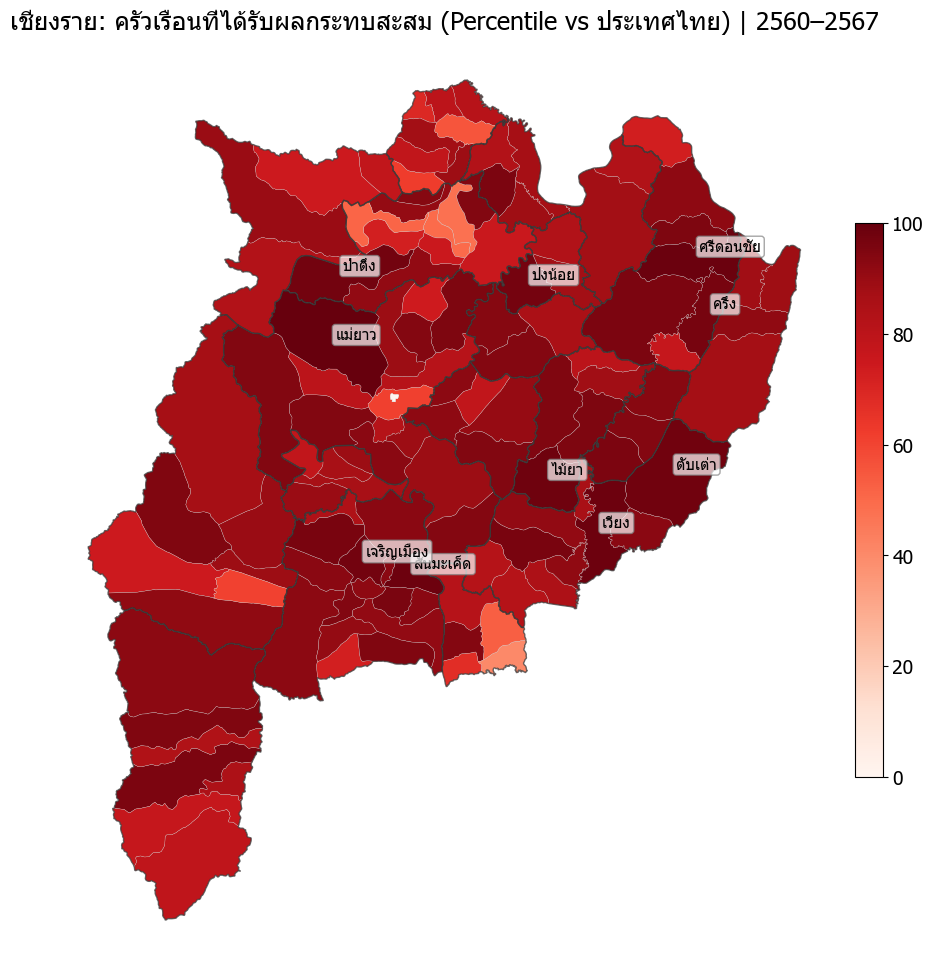

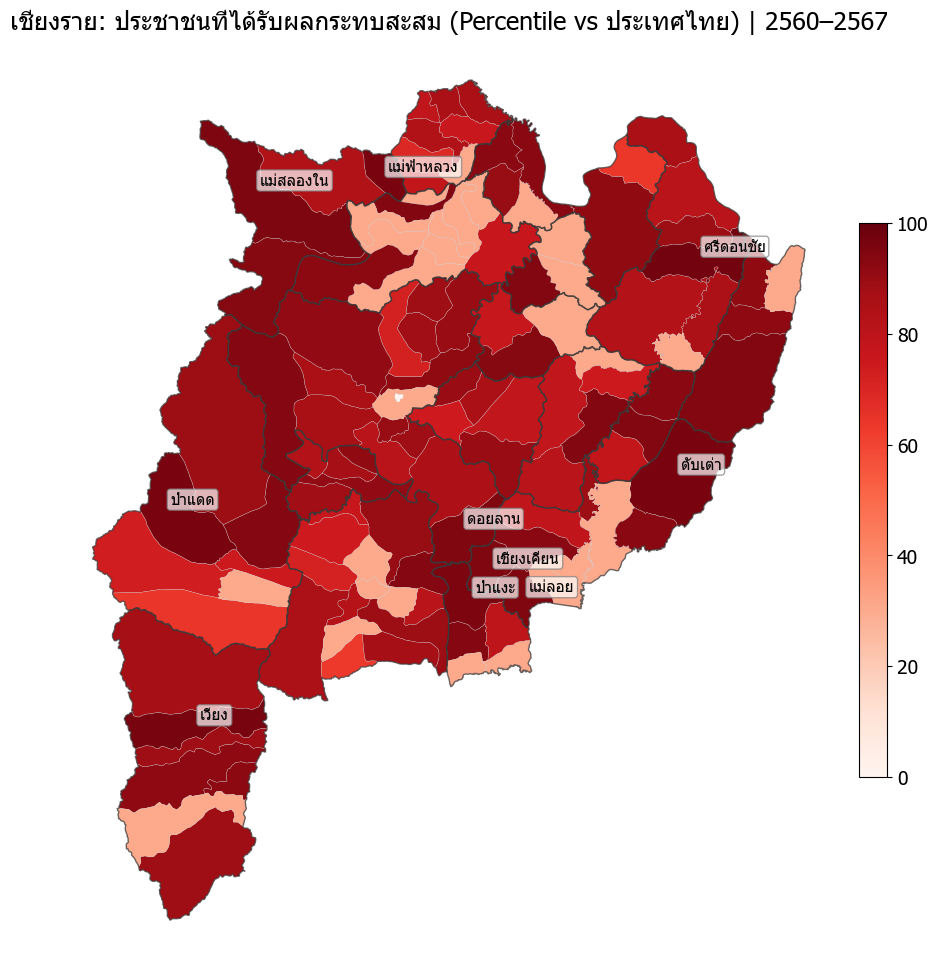

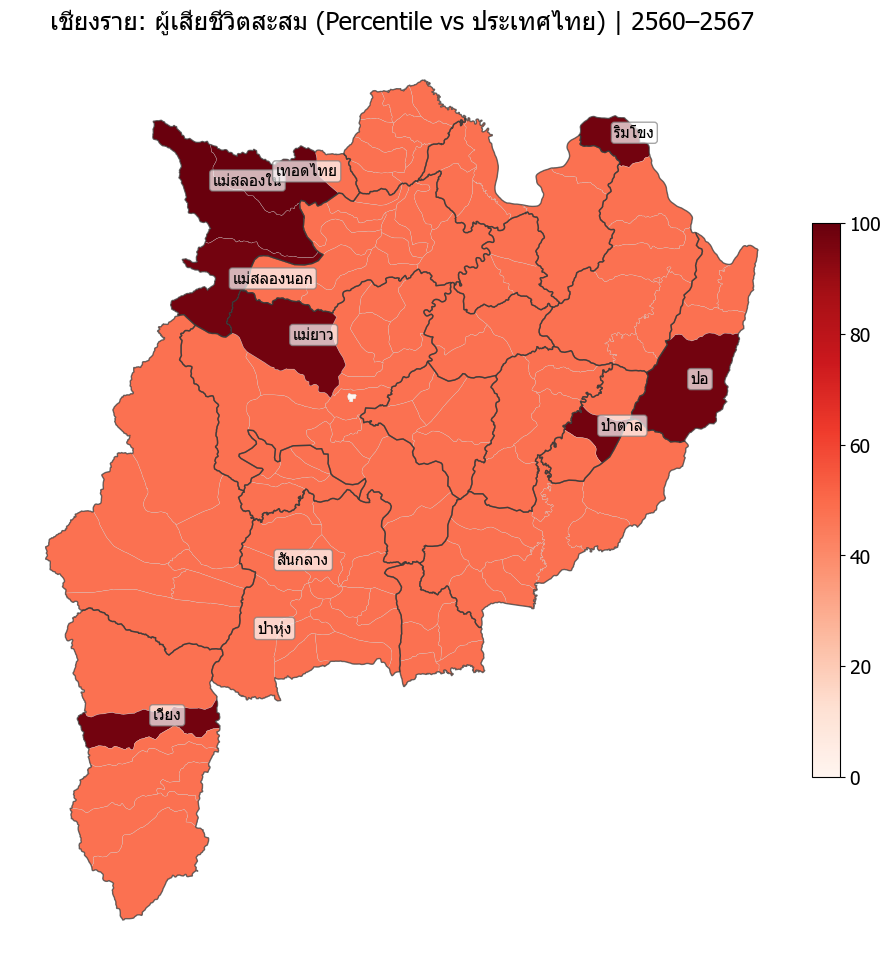

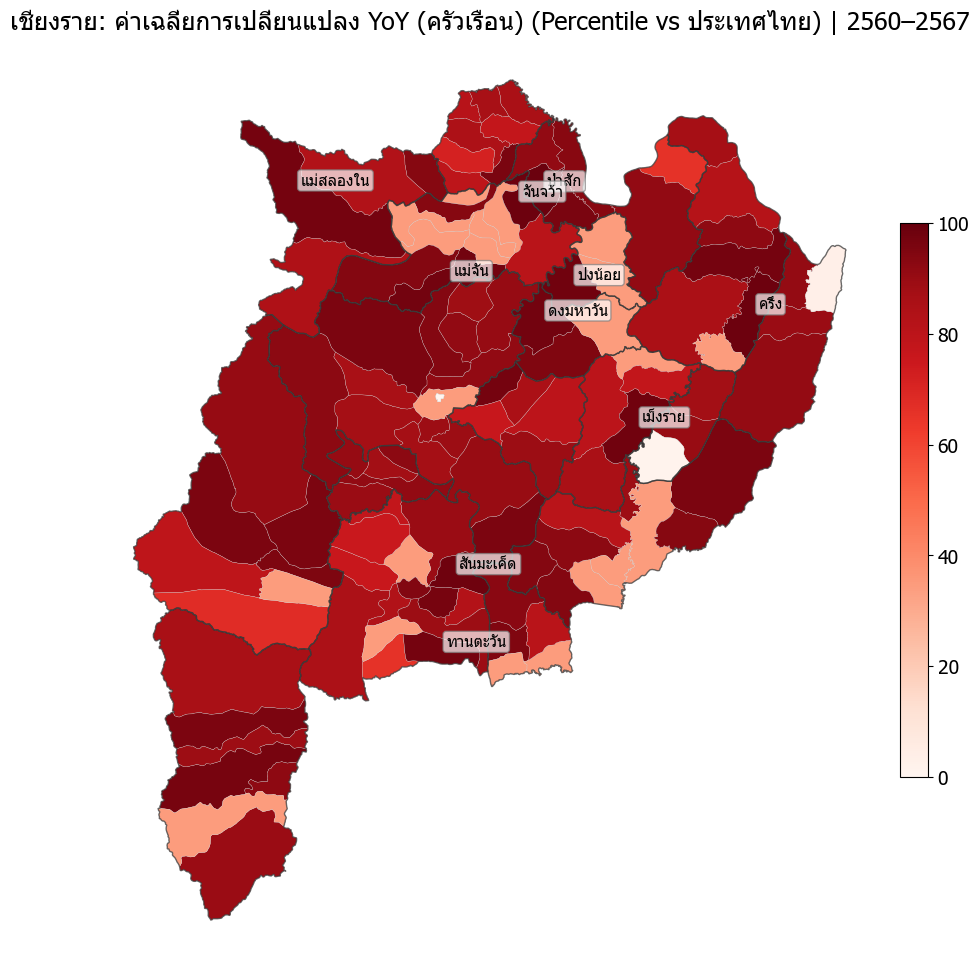

In [7]:
PROVINCE_CODE_CR = '57'

# Filter Chiang Rai geometry+metrics via code prefix only (no name fallback)
cr = map_df.loc[map_df['subdist_cd'].astype(str).str.startswith(PROVINCE_CODE_CR)].copy()
print('Chiang Rai rows (geometry):', len(cr))

# Percentile columns expected from Gold fact
pct_cols = [
    'pct_national_affected_households_sum',
    'pct_national_affected_people_sum',
    'pct_national_deaths_sum',
    'pct_national_avg_yoy_change',
]
missing_pct = [c for c in pct_cols if c not in cr.columns]
if missing_pct:
    raise KeyError('Missing percentile columns in joined map_df: ' + str(missing_pct))

# Ensure numeric
for c in pct_cols:
    cr[c] = pd.to_numeric(cr[c], errors='coerce').fillna(0.0)

# District boundaries for overlay (optional but makes maps readable)
districts_cr = None
if 'A_NAME_T' in cr.columns:
    try:
        districts_cr = cr.dissolve(by='A_NAME_T')
    except Exception:
        districts_cr = None

def _label_tambon(row: pd.Series) -> str:
    # Prefer authoritative Gold spine names if present; fallback to shapefile field
    for c in ['subdistrict_name_th', 'T_NAME_T']:
        if c in row and pd.notna(row[c]) and str(row[c]).strip():
            return str(row[c]).strip()
    return str(row.get('subdist_cd', '')).strip()

def plot_chiang_rai_percentile(metric_pct_col: str, title_th: str) -> None:
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    ax.set_axis_off()
    ax.set_title(f'เชียงราย: {title_th} (Percentile vs ประเทศไทย) | 2560–2567', fontsize=18)

    # Percentiles are computed at Gold build time across ALL tambons nationwide (0..100).
    cr.plot(
        column=metric_pct_col,
        ax=ax,
        cmap='Reds',
        legend=True,
        legend_kwds={
            'shrink': 0.6,
            'fraction': 0.03,
            'pad': 0.02,
        },
        vmin=0,
        vmax=100,
        linewidth=0.2,
        edgecolor='#CCCCCC',
    )

    if districts_cr is not None:
        try:
            districts_cr.boundary.plot(ax=ax, color='#333333', linewidth=1.0, alpha=0.7)
        except Exception:
            pass

    # Annotate top 10 tambons within Chiang Rai by percentile
    top10 = cr.sort_values(metric_pct_col, ascending=False).head(10).copy()
    for _, r in top10.iterrows():
        try:
            pt = r.geometry.representative_point()
            ax.annotate(
                text=_label_tambon(r),
                xy=(pt.x, pt.y),
                xytext=(3, 3),
                textcoords='offset points',
                fontsize=11,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='0.5'),
            )
        except Exception:
            continue

    plt.show()

chiang_rai_maps = [
    ('pct_national_affected_households_sum', 'ครัวเรือนที่ได้รับผลกระทบสะสม'),
    ('pct_national_affected_people_sum', 'ประชาชนที่ได้รับผลกระทบสะสม'),
    ('pct_national_deaths_sum', 'ผู้เสียชีวิตสะสม'),
    ('pct_national_avg_yoy_change', 'ค่าเฉลี่ยการเปลี่ยนแปลง YoY (ครัวเรือน)'),
]

for col, title_th in chiang_rai_maps:
    plot_chiang_rai_percentile(col, title_th)


Yearly metric columns:
 - affected_households_sum
 - affected_people_sum
 - deaths_sum
 - province_code_x
 - province_code_y
 - yoy_delta_affected_households


,year_be,affected_households_sum,affected_people_sum,deaths_sum,province_code_x,province_code_y,yoy_delta_affected_households
0,2560,94783.0,0.0,29.0,24207.0,343758,0.0
1,2561,186927.0,0.0,42.0,154906.0,343758,92144.0
2,2562,461947.0,0.0,47.0,201840.0,343758,275020.0
3,2563,294881.0,0.0,38.0,179558.0,343758,-167066.0
4,2564,223256.0,0.0,49.0,199974.0,343758,-71625.0
5,2565,360156.0,4553.0,50.0,223635.0,343758,136900.0
6,2566,422059.0,596678.0,50.0,194538.0,343758,61903.0
7,2567,507316.0,885166.0,119.0,267631.0,343758,85257.0


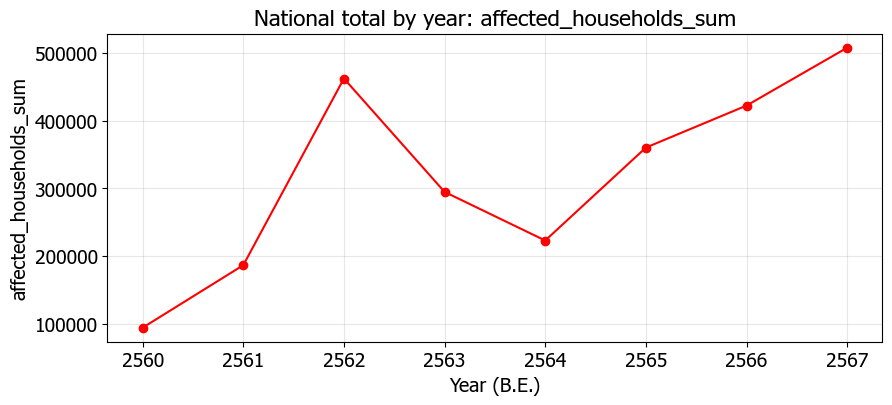

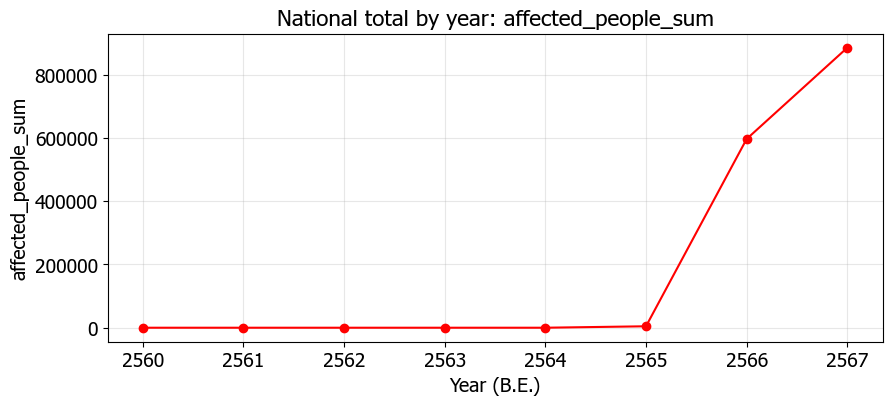

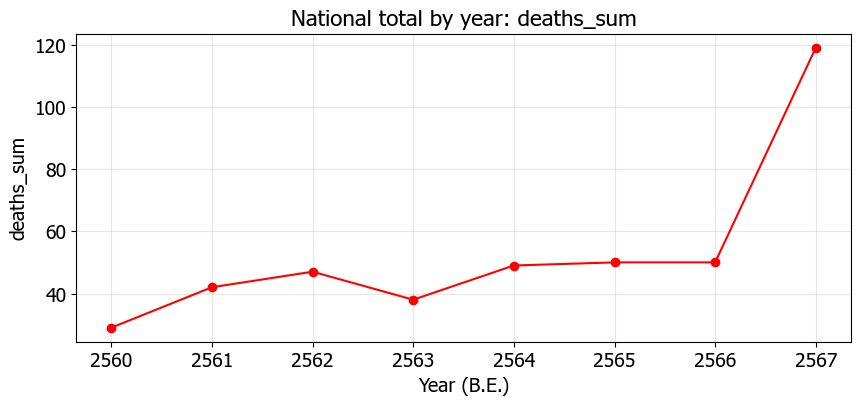

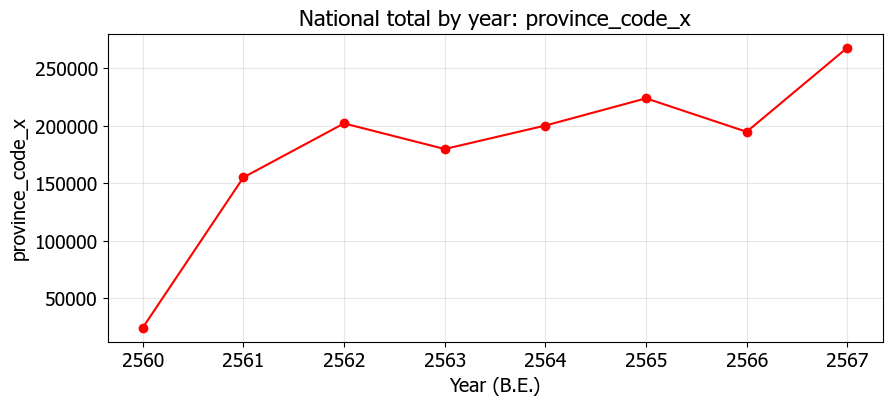

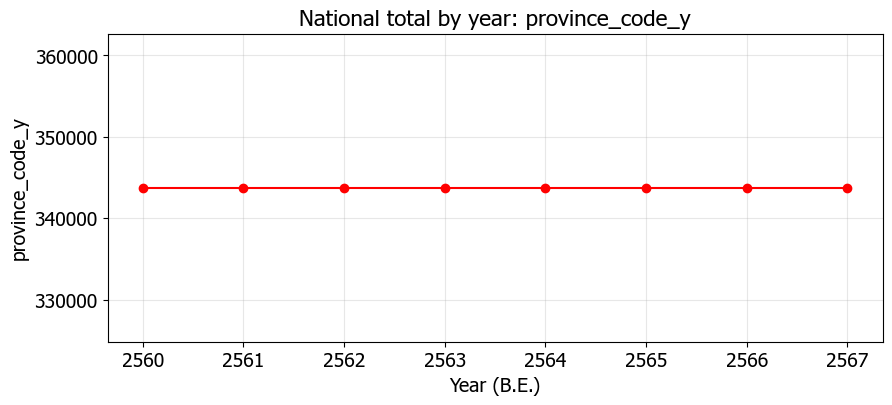

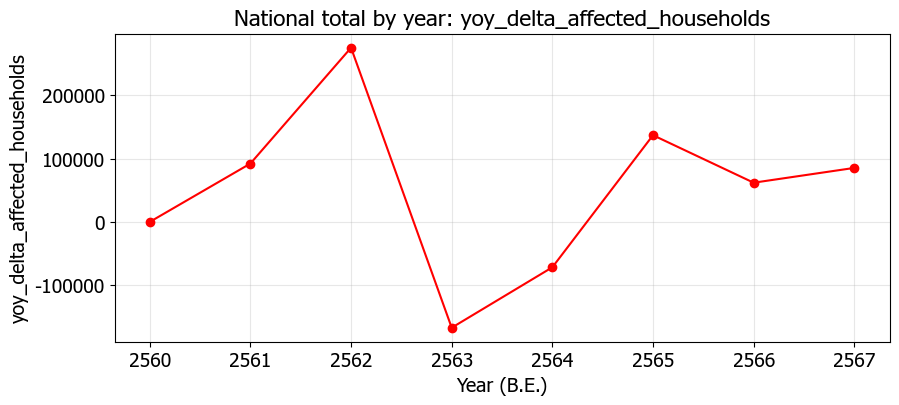

In [8]:
yearly = yearly.copy()
yearly['subdistrict_code'] = _clean_code_6(yearly.get('subdistrict_code', pd.Series(dtype=str)))
yearly['year_be'] = pd.to_numeric(yearly.get('year_be', pd.Series(dtype=float)), errors='coerce')
yearly = yearly.loc[yearly['subdistrict_code'].ne('')].copy()

# Discover yearly metric columns
yearly_id = {'subdistrict_code', 'province_code', 'year_be'}
yearly_metrics = [c for c in yearly.columns if c not in yearly_id and pd.api.types.is_numeric_dtype(yearly[c])]
yearly_metrics = sorted(yearly_metrics)
print('Yearly metric columns:')
for c in yearly_metrics:
    print(' -', c)

# National totals by year
nat_year = yearly.groupby('year_be', as_index=False).agg({m: 'sum' for m in yearly_metrics})
display(nat_year)

for m in yearly_metrics:
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    ax.plot(nat_year['year_be'], nat_year[m], marker='o', color='red')
    ax.set_title(f'National total by year: {m}')
    ax.set_xlabel('Year (B.E.)')
    ax.set_ylabel(m)
    ax.grid(True, alpha=0.3)
    plt.show()
